# What drives the price? Self-service, fuel grade, brand, motorway location

01_price_distribution.ipynb established the national snapshot's overall shape. This notebook asks what explains the *spread* around that: is it self-service vs. full-service, the fuel grade, the brand, or being on the motorway (`station_type = 'Autostradale'`)?

These factors are correlated with each other (autostrada stations tend to be full-service; particular brands cluster in particular areas), so a plain groupby-mean per factor risks misattributing one factor's effect to another. We use an OLS regression (`price ~ self_service + fuel_description + brand_name + station_type`) to estimate each factor's effect while holding the others constant, then zoom in on the supermarket-chain brands, which turn out to be the cheapest category of all.

The second half of the notebook re-asks the question directionally: given how tightly prices cluster, what makes a station price *above* versus *below* its peer group's modal price, via an ordered logistic regression.

In [1]:
import numpy as np
import pandas as pd
import patsy
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel

from app.services.mirror import Mirror

# Read-only DuckDB mirror, not the live Postgres DB.
con = Mirror().connect(read_only=True)
con.execute("SET enable_progress_bar = false")
SNAPSHOT_DATE = '2026-08-31'

## Pull a station sample

We take a random sample of active stations and pull their prices directly from the mirror's `price_change` table, using the same `min/max_extraction_date` bracket as `prices_daily_mirror` but skipping the macro's `generate_series`/`CROSS JOIN` machinery since we only need a single date. A few thousand stations is statistically plenty for a regression like this. (The mirror is a local single-file DuckDB database, so these queries don't compete with the live app or any running backfill for I/O.)

In [2]:
ids = con.execute('''
    SELECT station_id FROM station
    WHERE extraction_date >= '2026-07-21'
    ORDER BY random() LIMIT 1500
''').df()['station_id'].tolist()

prices = con.execute('''
    SELECT station_id, fuel_description, self_service, price
    FROM price_change
    WHERE station_id = ANY(?)
      AND min_extraction_date <= ? AND max_extraction_date >= ?
''', [ids, SNAPSHOT_DATE, SNAPSHOT_DATE]).df()

prices['price'] = prices['price'].astype(float)
prices = prices[prices['price'] > 0]
len(prices)

5896

In [3]:
station_ids = prices['station_id'].unique().tolist()
stations = con.execute(
    'SELECT station_id, brand_name, station_type FROM station WHERE station_id = ANY(?)',
    [station_ids],
).df()

df = prices.merge(stations, on='station_id', how='inner')
df.shape

(5896, 6)

## Restrict to fuel types and brands with enough observations

The sample includes a long tail of niche fuel grades (some premium blends, HVO variants, etc.) with only a handful of stations each - not enough to estimate a stable effect for. Keep fuel types with at least 50 observations in the sample; everything else gets folded into an explicit `Other` bucket rather than dropped, so it's visible in the regression as a (necessarily noisier) category rather than silently discarded.

In [4]:
fuel_counts = df['fuel_description'].value_counts()
common_fuels = fuel_counts[fuel_counts >= 50].index
df['fuel_group'] = df['fuel_description'].where(df['fuel_description'].isin(common_fuels), 'Other')

brand_counts = df['brand_name'].value_counts()
common_brands = brand_counts[brand_counts >= 20].index
df['brand_group'] = df['brand_name'].where(df['brand_name'].isin(common_brands), 'Other').fillna('Unknown')

df['fuel_group'].value_counts()

fuel_group
Benzina           2166
Gasolio           2164
Blue Diesel        355
GPL                317
Other              289
HVOlution          149
Supreme Diesel     100
Hi-Q Diesel         97
Blue Super          94
Metano              90
HVO                 75
Name: count, dtype: int64

## Regression

`price ~ self_service + fuel_group + brand_group + station_type`, with `Benzina` / the most common brand / `Stradale` as the implicit baseline (whichever category `statsmodels` picks first alphabetically - check the intercept's category via the model summary). Each coefficient is the estimated EUR/L effect of that category *relative to the baseline*, holding the other factors constant.

In [5]:
model = smf.ols('price ~ self_service + C(fuel_group) + C(brand_group) + C(station_type)', data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     1368.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:52:32   Log-Likelihood:                 4254.8
No. Observations:                5896   AIC:                            -8436.
Df Residuals:                    5859   BIC:                            -8188.
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 2.3157      0.009    251.729      0.000       2.298       2.334
self_service[T.True]                     -0.1352      0.003    -41.724      0.000      -0.142      -0.129
C(fuel_group)[T.Blue Diesel]              0.2080      0.008     27.590      0.000       0.193       0.223
C(fuel_group)[T.Blue Super]               0.0515      0.013      3.998      0.000       0.026       0.077
C(fuel_group)[T.GPL]                     -1.3866      0.007   -187.956      0.000      -1.401      -1.372
C(fuel_group)[T.Gasolio]                  0.1152      0.004     32.141      0.000       0.108       0.122
C(fuel_group)[T.HVO]                      0.1029      0.014      7.328      0.000       0.075       0.130
C(fuel_group)[T.HVOlution]                0.0944      0.011      8.960      0.000       0.074       0.115
C(fuel_group)[T.Hi-Q Diesel]              0.3352      0.013     25.625      0.000       0.310       0.361
C(fuel_group)[T.Metano]                  -0.5022      0.013    -39.062      0.000      -0.527      -0.477
C(fuel_group)[T.Other]                    0.1267      0.008     16.308      0.000       0.111       0.142
C(fuel_group)[T.Supreme Diesel]           0.2609      0.013     20.063      0.000       0.235       0.286
C(brand_group)[T.Ala]                     0.0156      0.025      0.627      0.530      -0.033       0.065
C(brand_group)[T.Api-Ip]                 -0.0171      0.006     -3.003      0.003      -0.028      -0.006
C(brand_group)[T.Aquila]                 -0.0118      0.018     -0.666      0.505      -0.046       0.023
C(brand_group)[T.BC]                     -0.1201      0.024     -5.080      0.000      -0.166      -0.074
C(brand_group)[T.Beyfin]                 -0.0767      0.020     -3.825      0.000      -0.116      -0.037
C(brand_group)[T.Costantin]              -0.0866      0.015     -5.703      0.000      -0.116      -0.057
C(brand_group)[T.Ego]                    -0.0568      0.019     -2.971      0.003      -0.094      -0.019
C(brand_group)[T.Energas]                -0.1014      0.015     -6.928      0.000      -0.130      -0.073
C(brand_group)[T.Enerpetroli]            -0.0607      0.023     -2.588      0.010      -0.107      -0.015
C(brand_group)[T.Esso]                   -0.0044      0.006     -0.683      0.494      -0.017       0.008
C(brand_group)[T.Europam]                -0.0577      0.023     -2.457      0.014      -0.104      -0.012
C(brand_group)[T.Giap]                   -0.0537      0.023     -2.374      0.018      -0.098      -0.009
C(brand_group)[T.Italiana Carburanti]    -0.0146      0.027     -0.548      0.584      -0.067       0.038
C(brand_group)[T.KEROPETROL]             -0.1198      0.021     -5.810      0.000      -0.160      -0.079
C(brand_g

## Interpretation

Pull out the headline effects: self-service saving, and the motorway (`Autostradale`) premium, with their confidence intervals.

In [6]:
params = model.params
conf = model.conf_int()

for label in params.index:
    if 'self_service' in label or 'station_type' in label:
        lo, hi = conf.loc[label]
        print(f"{label}: {params[label]:+.3f} EUR/L  (95% CI {lo:+.3f} to {hi:+.3f})")

self_service[T.True]: -0.135 EUR/L  (95% CI -0.142 to -0.129)
C(station_type)[T.Stradale]: -0.130 EUR/L  (95% CI -0.147 to -0.114)


In [7]:
brand_effects = params[[l for l in params.index if 'brand_group' in l]].sort_values()
brand_effects

C(brand_group)[T.BC]                    -0.120069
C(brand_group)[T.KEROPETROL]            -0.119846
C(brand_group)[T.Energas]               -0.101400
C(brand_group)[T.Loro]                  -0.100079
C(brand_group)[T.Costantin]             -0.086611
C(brand_group)[T.Pompe Bianche]         -0.084401
C(brand_group)[T.Lukoil]                -0.083971
C(brand_group)[T.Beyfin]                -0.076749
C(brand_group)[T.Shell]                 -0.068783
C(brand_group)[T.Tamoil]                -0.065889
C(brand_group)[T.Other]                 -0.060709
C(brand_group)[T.Enerpetroli]           -0.060668
C(brand_group)[T.Vega]                  -0.060208
C(brand_group)[T.Retitalia]             -0.058221
C(brand_group)[T.Europam]               -0.057686
C(brand_group)[T.Ego]                   -0.056757
C(brand_group)[T.Giap]                  -0.053693
C(brand_group)[T.San Marco Petroli]     -0.035411
C(brand_group)[T.Q8]                    -0.030327
C(brand_group)[T.Api-Ip]                -0.017065


## Supermarket forecourts

The cheap end of the brand ladder above is discount and no-name brands - but the
six supermarket-chain forecourts in the data (CONAD, Coop's *Enercoop* and
*COOP*, *Auchan*, *Iper*) are cheaper still, and the 1,500-station sample above
barely contains any. Pull every `Benzina` self-service price for the snapshot and
score each supermarket brand against a station-type + latitude baseline (latitude
standing in for the north-south price gradient; brand left out, so brand *is*
what's being measured).

In [8]:
SUPERMARKET_BRANDS = ['CONAD', 'Enercoop', 'Auchan', 'Iper Station', 'COOP', 'Carrefour']
DUTY_FREE_COMUNI = {'LIVIGNO', 'CAMPIONE', "CAMPIONE D'ITALIA"}   # extra-customs enclaves, ~40c cheaper

sm = con.execute("""
    SELECT pc.price::double AS price, s.brand_name, s.station_type, s.latitude, s.comune
    FROM price_change pc JOIN station s USING (station_id)
    WHERE pc.fuel_description = 'Benzina' AND pc.self_service = true AND pc.price > 0
      AND pc.min_extraction_date <= ? AND pc.max_extraction_date >= ?
""", [SNAPSHOT_DATE, SNAPSHOT_DATE]).df().dropna(subset=['latitude'])
sm = sm[~sm['comune'].str.upper().isin(DUTY_FREE_COMUNI)]
sm['supermarket'] = sm['brand_name'].isin(SUPERMARKET_BRANDS)

baseline = smf.ols('price ~ C(station_type) + latitude', data=sm).fit()
sm['vs_baseline'] = (sm['price'] - baseline.predict(sm)) * 100   # cents/L vs type + latitude

print(sm[sm['supermarket']].groupby('brand_name')['vs_baseline']
        .agg(['mean', 'count']).sort_values('mean').round(2))

flag = smf.ols('price ~ C(station_type) + latitude + supermarket', data=sm).fit()
print(f"\nsupermarket vs every other brand: {flag.params['supermarket[T.True]'] * 100:+.2f} cents/L "
      f"(p = {flag.pvalues['supermarket[T.True]']:.0e}, n = {int(sm['supermarket'].sum())})")
print(f"unbranded 'Pompe Bianche' for comparison: "
      f"{sm.loc[sm['brand_name'] == 'Pompe Bianche', 'vs_baseline'].mean():+.2f} cents/L")

              mean  count
brand_name               
Auchan       -5.51     20
CONAD        -4.19     52
Enercoop     -3.88     30
COOP         -3.44      5
Iper Station -2.86     14
Carrefour    -1.01      5

supermarket vs every other brand: -4.05 cents/L (p = 1e-21, n = 126)
unbranded 'Pompe Bianche' for comparison: -1.59 cents/L


Consistently cheap. CONAD, Enercoop/COOP (Coop) and Auchan all sit **3-6 cents/L
below** what their road type and latitude predict, Iper a little less; as one
group it's about **-4 cents/L (p ~ 1e-21)** across ~130 stations - undercutting
even the unbranded "Pompe Bianche" pumps (~-1.5) and the discount majors
(Tamoil, Q8). Supermarket forecourts are the cheapest identifiable category of
station in the data. Carrefour is the exception at ~-1, but on only five
stations; Auchan's grocery arm was sold to Conad in 2020, so that brand is a
shrinking network. `03_geography.ipynb` picks one of these apart in detail
(station 9233, a CONAD).

## Above or below the modal? A directional view

The regression above measures each factor's effect in cents/L. This section asks
a different question, prompted by how tightly prices cluster: on any given day
~90% of prices for a fuel and service level sit within a few cents of that
group's *modal* price. So rather than "how many cents", ask **which direction** -
what makes a station price *above* its peers' modal price, and what makes it
price *below*?

"Peers" here is the same fuel type and self-service setting on the same day: that
day's modal cent for the `(fuel, self_service)` cell is the reference, so the
contrast isolates brand and road type rather than the fuel/service differences
the first regression already covered.

Each station-price is labelled `below` / `at` / `above` that modal cent, and we
fit an **ordered logistic regression** over those three ordered outcomes. A
positive coefficient raises the odds of pricing higher (`below`->`at`->`above`);
the exponentiated coefficient is that odds ratio.

### Building the panel

We sample the 15th of each quarter from 2017 to 2025 (36 days, spanning the
low-price 2020 trough and the 2022-23 peak), take a fixed ~1-in-`SAMPLE_MOD`
slice of stations by id, and for every active price compute the modal cent of
its `(day, fuel, self_service)` cell. Cells with fewer than 150 sampled stations
are dropped. Raising `SAMPLE_MOD` trims the row count and the model fit (~30-45s
at the default).

In [9]:
SAMPLE_MOD = 20
SAMPLE_DAYS = [f"{y}-{m:02d}-15" for y in range(2017, 2026) for m in (1, 4, 7, 10)]

dev_query = """
WITH sample_days AS (
    SELECT unnest(?::date[]) AS d
),
priced AS (
    SELECT s.d, pc.station_id, pc.fuel_description, pc.self_service,
           round(pc.price, 2)::double AS price_cent
    FROM sample_days s
    JOIN price_change pc
      ON pc.min_extraction_date <= s.d
     AND pc.max_extraction_date >= s.d
    WHERE pc.price > 0 AND pc.station_id % ? = 0
),
cell_mode AS (
    SELECT d, fuel_description, self_service,
           mode(price_cent) AS modal_cent,
           count(*)         AS n_cell
    FROM priced
    GROUP BY 1, 2, 3
)
SELECT p.d, p.station_id, p.fuel_description, p.self_service,
       p.price_cent, c.modal_cent,
       CASE WHEN p.price_cent < c.modal_cent THEN 'below'
            WHEN p.price_cent > c.modal_cent THEN 'above'
            ELSE 'at' END AS direction
FROM priced p
JOIN cell_mode c USING (d, fuel_description, self_service)
WHERE c.n_cell >= 150
"""

dev = con.execute(dev_query, [SAMPLE_DAYS, SAMPLE_MOD]).df()
print(f"{len(dev):,} station-prices over {dev['d'].nunique()} days")
dev['direction'].value_counts(normalize=True).round(3)

140,394 station-prices over 36 days


direction
above    0.479
below    0.419
at       0.101
Name: proportion, dtype: float64

In [10]:
stations = con.execute("""
    SELECT station_id, brand_name, station_type
    FROM station
""").df()

dev = dev.merge(stations, on='station_id', how='inner').dropna(
    subset=['brand_name', 'station_type'])

# Bucket the long tail of fuels and brands (thresholds scaled to this panel's size)
fuel_counts = dev['fuel_description'].value_counts()
dev['fuel_group'] = dev['fuel_description'].where(
    dev['fuel_description'].isin(fuel_counts[fuel_counts >= 2000].index), 'Other')

brand_counts = dev['brand_name'].value_counts()
dev['brand_group'] = dev['brand_name'].where(
    dev['brand_name'].isin(brand_counts[brand_counts >= 1500].index), 'Other')

# Order the outcome; set the reference category for each factor
dev['direction'] = pd.Categorical(dev['direction'], ['below', 'at', 'above'], ordered=True)
for col, ref in [('fuel_group', 'Benzina'), ('brand_group', 'Agip Eni'), ('station_type', 'Stradale')]:
    dev[col] = pd.Categorical(dev[col], [ref] + sorted(set(dev[col]) - {ref}))

dev.shape

(140394, 11)

In [11]:
# Assumption-free first look: share below / at / above by road type and by brand
def rate_table(col):
    t = (dev.groupby(col, observed=True)['direction']
            .value_counts(normalize=True).unstack()[['below', 'at', 'above']])
    t['n'] = dev.groupby(col, observed=True).size()
    return t.sort_values('above').round(3)


print(rate_table('station_type'), '\n')
print(rate_table('brand_group'))

direction       below     at  above       n
station_type                               
Stradale        0.437  0.107  0.456  118996
Altro           0.384  0.078  0.538   15256
Strada Statale  0.340  0.077  0.583    2767
Autostradale    0.027  0.029  0.944    3375 

direction      below     at  above      n
brand_group                              
Pompe Bianche  0.630  0.094  0.275  20264
Other          0.530  0.094  0.376  22553
Tamoil         0.485  0.089  0.426  10016
Q8             0.381  0.111  0.509  15400
Esso           0.341  0.093  0.566  14414
Agip Eni       0.311  0.120  0.570  31434
Api-Ip         0.332  0.095  0.573  26313


The overall split is roughly 41% below / 10% at / 49% above - not 45/10/45.
Because the price spike is lumpy and slightly right-shouldered (see
`01_price_distribution.ipynb`), the modal cent usually sits just below the middle
of the cluster, so "above the mode" is the majority outcome even with no other
effect. The ordered-logit cut-points absorb that baseline; every coefficient
below is *relative to its reference category* (Benzina / Agip Eni / `Stradale`),
which is what we care about.

In [12]:
X = patsy.dmatrix(
    'C(fuel_group) + self_service + C(brand_group) + C(station_type)',
    dev, return_type='dataframe').drop(columns='Intercept')

ord_model = OrderedModel(dev['direction'].cat.codes.values, X.values, distr='logit').fit(
    method='lbfgs', maxiter=300, disp=False)

res = pd.DataFrame({'coef': ord_model.params[:X.shape[1]],
                    'se':   ord_model.bse[:X.shape[1]]}, index=X.columns)
res['odds_ratio'] = np.exp(res['coef'])
res['z'] = res['coef'] / res['se']
res.sort_values('coef').round(3)

,coef,se,odds_ratio,z
C(brand_group)[T.Pompe Bianche],-1.342,0.019,0.261,-70.707
C(brand_group)[T.Other],-1.000,0.018,0.368,-55.009
C(brand_group)[T.Tamoil],-0.812,0.023,0.444,-34.779
C(fuel_group)[T.Blue Diesel],-0.352,0.029,0.703,-12.246
C(brand_group)[T.Q8],-0.328,0.020,0.720,-16.505
C(brand_group)[T.Esso],-0.177,0.021,0.838,-8.562
C(brand_group)[T.Api-Ip],-0.111,0.017,0.895,-6.349
self_service[T.True],0.050,0.011,1.051,4.387
C(fuel_group)[T.Gasolio],0.226,0.011,1.253,20.175
C(fuel_group)[T.GPL],0.269,0.024,1.309,11.116


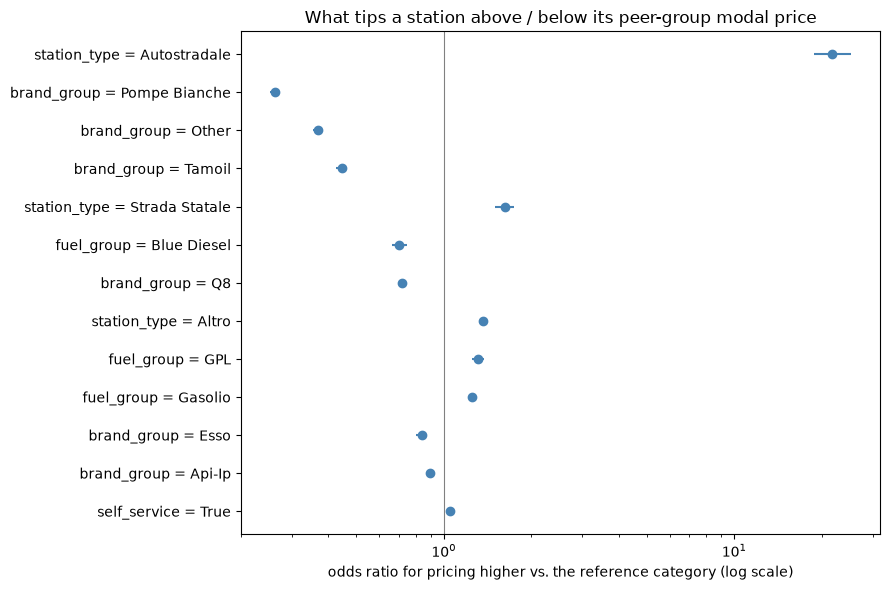

In [13]:
plot_df = res.reindex(res['coef'].abs().sort_values().index)
lo = np.exp(plot_df['coef'] - 1.96 * plot_df['se'])
hi = np.exp(plot_df['coef'] + 1.96 * plot_df['se'])

labels = [s.replace('C(', '').replace(')', '').replace('[T.', ' = ').rstrip(']')
          for s in plot_df.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(plot_df['odds_ratio'], range(len(plot_df)),
            xerr=[plot_df['odds_ratio'] - lo, hi - plot_df['odds_ratio']],
            fmt='o', color='steelblue')
ax.axvline(1, color='grey', linewidth=0.8)
ax.set_xscale('log')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels)
ax.set_xlabel('odds ratio for pricing higher vs. the reference category (log scale)')
ax.set_title('What tips a station above / below its peer-group modal price')
plt.tight_layout()
plt.show()

## Interpretation

**What pushes a price above the modal:**

- **Being on the motorway.** `Autostradale` stations have roughly *20x* the odds
  of pricing above their peer modal - by far the strongest single factor. In the
  raw table they sit above the mode over 90% of the time and are almost never
  below it. `Strada Statale` (trunk roads) and the `Altro` catch-all are clearly
  above ordinary `Stradale` stations too, though far less dramatically.
- **Flying a major integrated brand.** With Agip Eni as the reference, every
  other brand group has *lower* odds of pricing above the mode. Api-Ip and Esso
  are close behind; the gap widens through Q8 and Tamoil down to the unbranded
  `Pompe Bianche` and the small-brand `Other` bucket at ~0.25-0.35x - roughly
  3x more likely to sit *below* the mode than an Eni station. This is the same
  brand ladder the OLS found, seen as direction rather than cents.

**On the fuel and self-service coefficients:** the reference mode is computed
*within* each `(fuel, self_service)` cell, so these are not price-level effects -
they measure whether a group's spread is skewed above or below its own mode.
Gasolio and GPL lean above their modes, Blue Diesel below, and self-service is
marginally more above-skewed than full-service.

Location isn't in this model - which region a station sits in, and whether
proximity to a refinery matters, is taken up in `03_geography.ipynb`.

**Caveats:**

- Standard errors are optimistic - the same station appears on up to 36 sample
  days, so the observations are not independent. Trust the effect sizes and
  ordering, not the exact z-scores; even heavily discounted, the motorway and
  brand effects are nowhere near marginal.
- The modal cent is not the median (see the note above) and it shifts day to
  day; more sample days would sharpen the smaller brand contrasts.
- This is descriptive, not causal - an Eni-branded motorway station pricing high
  could be brand power, a captive location, higher site costs, or all three.